In [1]:
# --- Rutas del proyecto -------------------------------------------------
# Definición única en projects/mayanlab/mayanlab/paths.py. Funciona desde
# cualquier directorio de trabajo: no hay rutas relativas en este notebook.
from pathlib import Path

from mayanlab.paths import AUDIO, ANNOTATIONS, MANIFESTS, TRANSCRIPTS, LM_TEXT, ensure, project

P = project("analysis")
FIGURES, FEATURES, PDATA = P.figures, P.features, P.data
ensure(FIGURES, FEATURES)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

In [3]:
df = pd.read_csv(MANIFESTS / "final_dataset.csv")
df

,utt_id,maya,spk_id,path
0,spk_001_utt_0001,baach,spk_001,audios/spk_001_utt_0001.wav
1,spk_001_utt_0002,chiich,spk_001,audios/spk_001_utt_0002.wav
2,spk_001_utt_0003,ch'íich',spk_001,audios/spk_001_utt_0003.wav
3,spk_001_utt_0004,ja',spk_001,audios/spk_001_utt_0004.wav
4,spk_001_utt_0005,kool,spk_001,audios/spk_001_utt_0005.wav
...,...,...,...,...
2530,spk_032_utt_0223,jumpuul osea ma jumpuuli cada administración p...,spk_032,audios/spk_032_utt_0223.wav
2531,spk_032_utt_0224,como to'on láaj explicado to'on beeta'an to'on...,spk_032,audios/spk_032_utt_0224.wav
2532,spk_032_utt_0225,le ku xkáakpachtiko'obe ma tu pak'o'obi ma tu ...,spk_032,audios/spk_032_utt_0225.wav
2533,spk_032_utt_0226,teen xan man ti'ob weye camionadasil arroz kin...,spk_032,audios/spk_032_utt_0226.wav


In [4]:
textos = df["maya"].values
texto = ' '.join(textos)
texto

"baach chiich ch'íich' ja' kool k'i'ik' luuk' míis nool pool p'aak turix sojol teen t'uuch tsaats ts'aak waaj xamach yúuntun atan maak máak sa' ja'an nej peek' néen je' se'en ilib k'iin íicham k'ali' k'i'ix koj ch'oom sóol ch'o' to'on uj yuum úulum k'u' k'u'k'um chak cháak sak saak' sáak' saktal boox lela' juntúul box peek' k'an k'ank'an kan kaan ka'an k'a'am k'áan ya'ax yáax ya'axche ch'ooj chak k'an sam chak samal chak ba'ax lelo'oba' bix u boonil bix u boonilo'ob wíinkilal pool jo'ol tso'otsel pool chúuch kaal kaal keléembal tseem muuk' k'ab k'ab iim chuuchu' pool iim tso'otsel tseem tso'otsel xiik' xiik' nak' paach pu'uch báat k'ab t'o'olol paach tuuch chuun nak' kúuk t'e'et' kaal k'ab táan k'ab ch'ilbil k'ab aal k'ab paach k'ab u maamail k'ab tuuch'ub chúumukil ts'ipit t'uup íich'ak oot' tso'ots bak'el iit p'u'uk iit muuk' ook t'óon p'úulil ook tselek kaal ook tu'uk' ook ook paach ook ch'ilbil ook aak ook táan ook tuunkuy táan ich ich xikin le' xikin táan pool táan jo'ol táan ich 

In [5]:
from collections import Counter
import re
import pandas as pd

def analisis_lexico_completo(texto_corpus):
    """
    Análisis léxico exhaustivo del corpus
    """
    print("="*60)
    print("ANÁLISIS LÉXICO DEL CORPUS DE MAYA YUCATECO")
    print("="*60)
    
    # 1. Limpiar y tokenizar
    # Normalizar espacios
    texto_limpio = re.sub(r'\s+', ' ', texto_corpus)
    
    # Dividir en palabras (ajusta según tu ortografía)
    palabras = texto_limpio.lower().split()
    
    # Filtrar palabras vacías si es necesario
    palabras = [p for p in palabras if len(p) > 0]
    
    # 2. Estadísticas básicas
    print("\n📊 ESTADÍSTICAS GENERALES")
    print("-" * 60)
    total_tokens = len(palabras)
    vocabulario = set(palabras)
    total_unicas = len(vocabulario)
    
    print(f"Total de tokens (palabras):        {total_tokens:,}")
    print(f"Vocabulario (palabras únicas):     {total_unicas:,}")
    print(f"Type-Token Ratio (TTR):            {total_unicas/total_tokens:.4f}")
    print(f"Promedio tokens por palabra única: {total_tokens/total_unicas:.2f}")
    
    # 3. Frecuencia de palabras
    frecuencias = Counter(palabras)
    
    print("\n📈 DISTRIBUCIÓN DE FRECUENCIAS")
    print("-" * 60)
    print(f"Palabra más frecuente:  '{frecuencias.most_common(1)[0][0]}' ({frecuencias.most_common(1)[0][1]} veces)")
    
    # Hapax legomena (palabras que aparecen solo 1 vez)
    hapax = [palabra for palabra, freq in frecuencias.items() if freq == 1]
    print(f"Hapax legomena (freq=1): {len(hapax):,} ({len(hapax)/total_unicas*100:.1f}% del vocabulario)")
    
    # Palabras con freq=2
    dis_legomena = [palabra for palabra, freq in frecuencias.items() if freq == 2]
    print(f"Dis legomena (freq=2):   {len(dis_legomena):,} ({len(dis_legomena)/total_unicas*100:.1f}% del vocabulario)")
    
    # Cobertura
    top_100 = sum([freq for palabra, freq in frecuencias.most_common(100)])
    print(f"\nLas 100 palabras más frecuentes cubren: {top_100/total_tokens*100:.1f}% del corpus")
    
    top_500 = sum([freq for palabra, freq in frecuencias.most_common(500)])
    print(f"Las 500 palabras más frecuentes cubren: {top_500/total_tokens*100:.1f}% del corpus")
    
    # 4. Análisis de longitud
    longitudes = [len(p) for p in palabras]
    print("\n📏 LONGITUD DE PALABRAS")
    print("-" * 60)
    print(f"Longitud promedio:     {sum(longitudes)/len(longitudes):.2f} caracteres")
    print(f"Palabra más corta:     {min(longitudes)} caracteres")
    print(f"Palabra más larga:     {max(longitudes)} caracteres")
    
    # Ejemplos de palabras largas
    palabras_largas = sorted(vocabulario, key=len, reverse=True)[:5]
    print(f"Ejemplos más largas:   {', '.join(palabras_largas)}")
    
    # 5. Crear DataFrames para exportar
    df_frecuencias = pd.DataFrame(frecuencias.most_common(), 
                                  columns=['Palabra', 'Frecuencia'])
    df_frecuencias['Rank'] = range(1, len(df_frecuencias) + 1)
    df_frecuencias['Frecuencia Relativa'] = df_frecuencias['Frecuencia'] / total_tokens
    df_frecuencias['Freq. Acumulada'] = df_frecuencias['Frecuencia'].cumsum() / total_tokens
    
    # 6. Mostrar top palabras
    print("\n🔝 TOP 30 PALABRAS MÁS FRECUENTES")
    print("-" * 60)
    print(df_frecuencias.head(30).to_string(index=False))
    
    return {
        'total_tokens': total_tokens,
        'vocabulario': vocabulario,
        'total_unicas': total_unicas,
        'frecuencias': frecuencias,
        'df_frecuencias': df_frecuencias,
        'palabras_lista': palabras
    }

In [6]:
resultados = analisis_lexico_completo(texto)

ANÁLISIS LÉXICO DEL CORPUS DE MAYA YUCATECO

📊 ESTADÍSTICAS GENERALES
------------------------------------------------------------
Total de tokens (palabras):        34,154
Vocabulario (palabras únicas):     5,802
Type-Token Ratio (TTR):            0.1699
Promedio tokens por palabra única: 5.89

📈 DISTRIBUCIÓN DE FRECUENCIAS
------------------------------------------------------------
Palabra más frecuente:  'le' (1818 veces)
Hapax legomena (freq=1): 3,554 (61.3% del vocabulario)
Dis legomena (freq=2):   860 (14.8% del vocabulario)

Las 100 palabras más frecuentes cubren: 55.1% del corpus
Las 500 palabras más frecuentes cubren: 73.7% del corpus

📏 LONGITUD DE PALABRAS
------------------------------------------------------------
Longitud promedio:     4.61 caracteres
Palabra más corta:     1 caracteres
Palabra más larga:     19 caracteres
Ejemplos más largas:   tomojchi'itikeno'ob, xíimbalnako'one'ex, tsikbalnajo'one'ex, páa'tko'one'exo'ob, perseguirta'alo'ob

🔝 TOP 30 PALABRAS MÁS FREC

<>:30: SyntaxWarning: invalid escape sequence '\%'
<>:30: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_9311/3999759482.py:30: SyntaxWarning: invalid escape sequence '\%'
  ax2.set_ylabel('Cobertura del corpus (\%)', fontsize=11)
/tmp/ipykernel_9311/3999759482.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


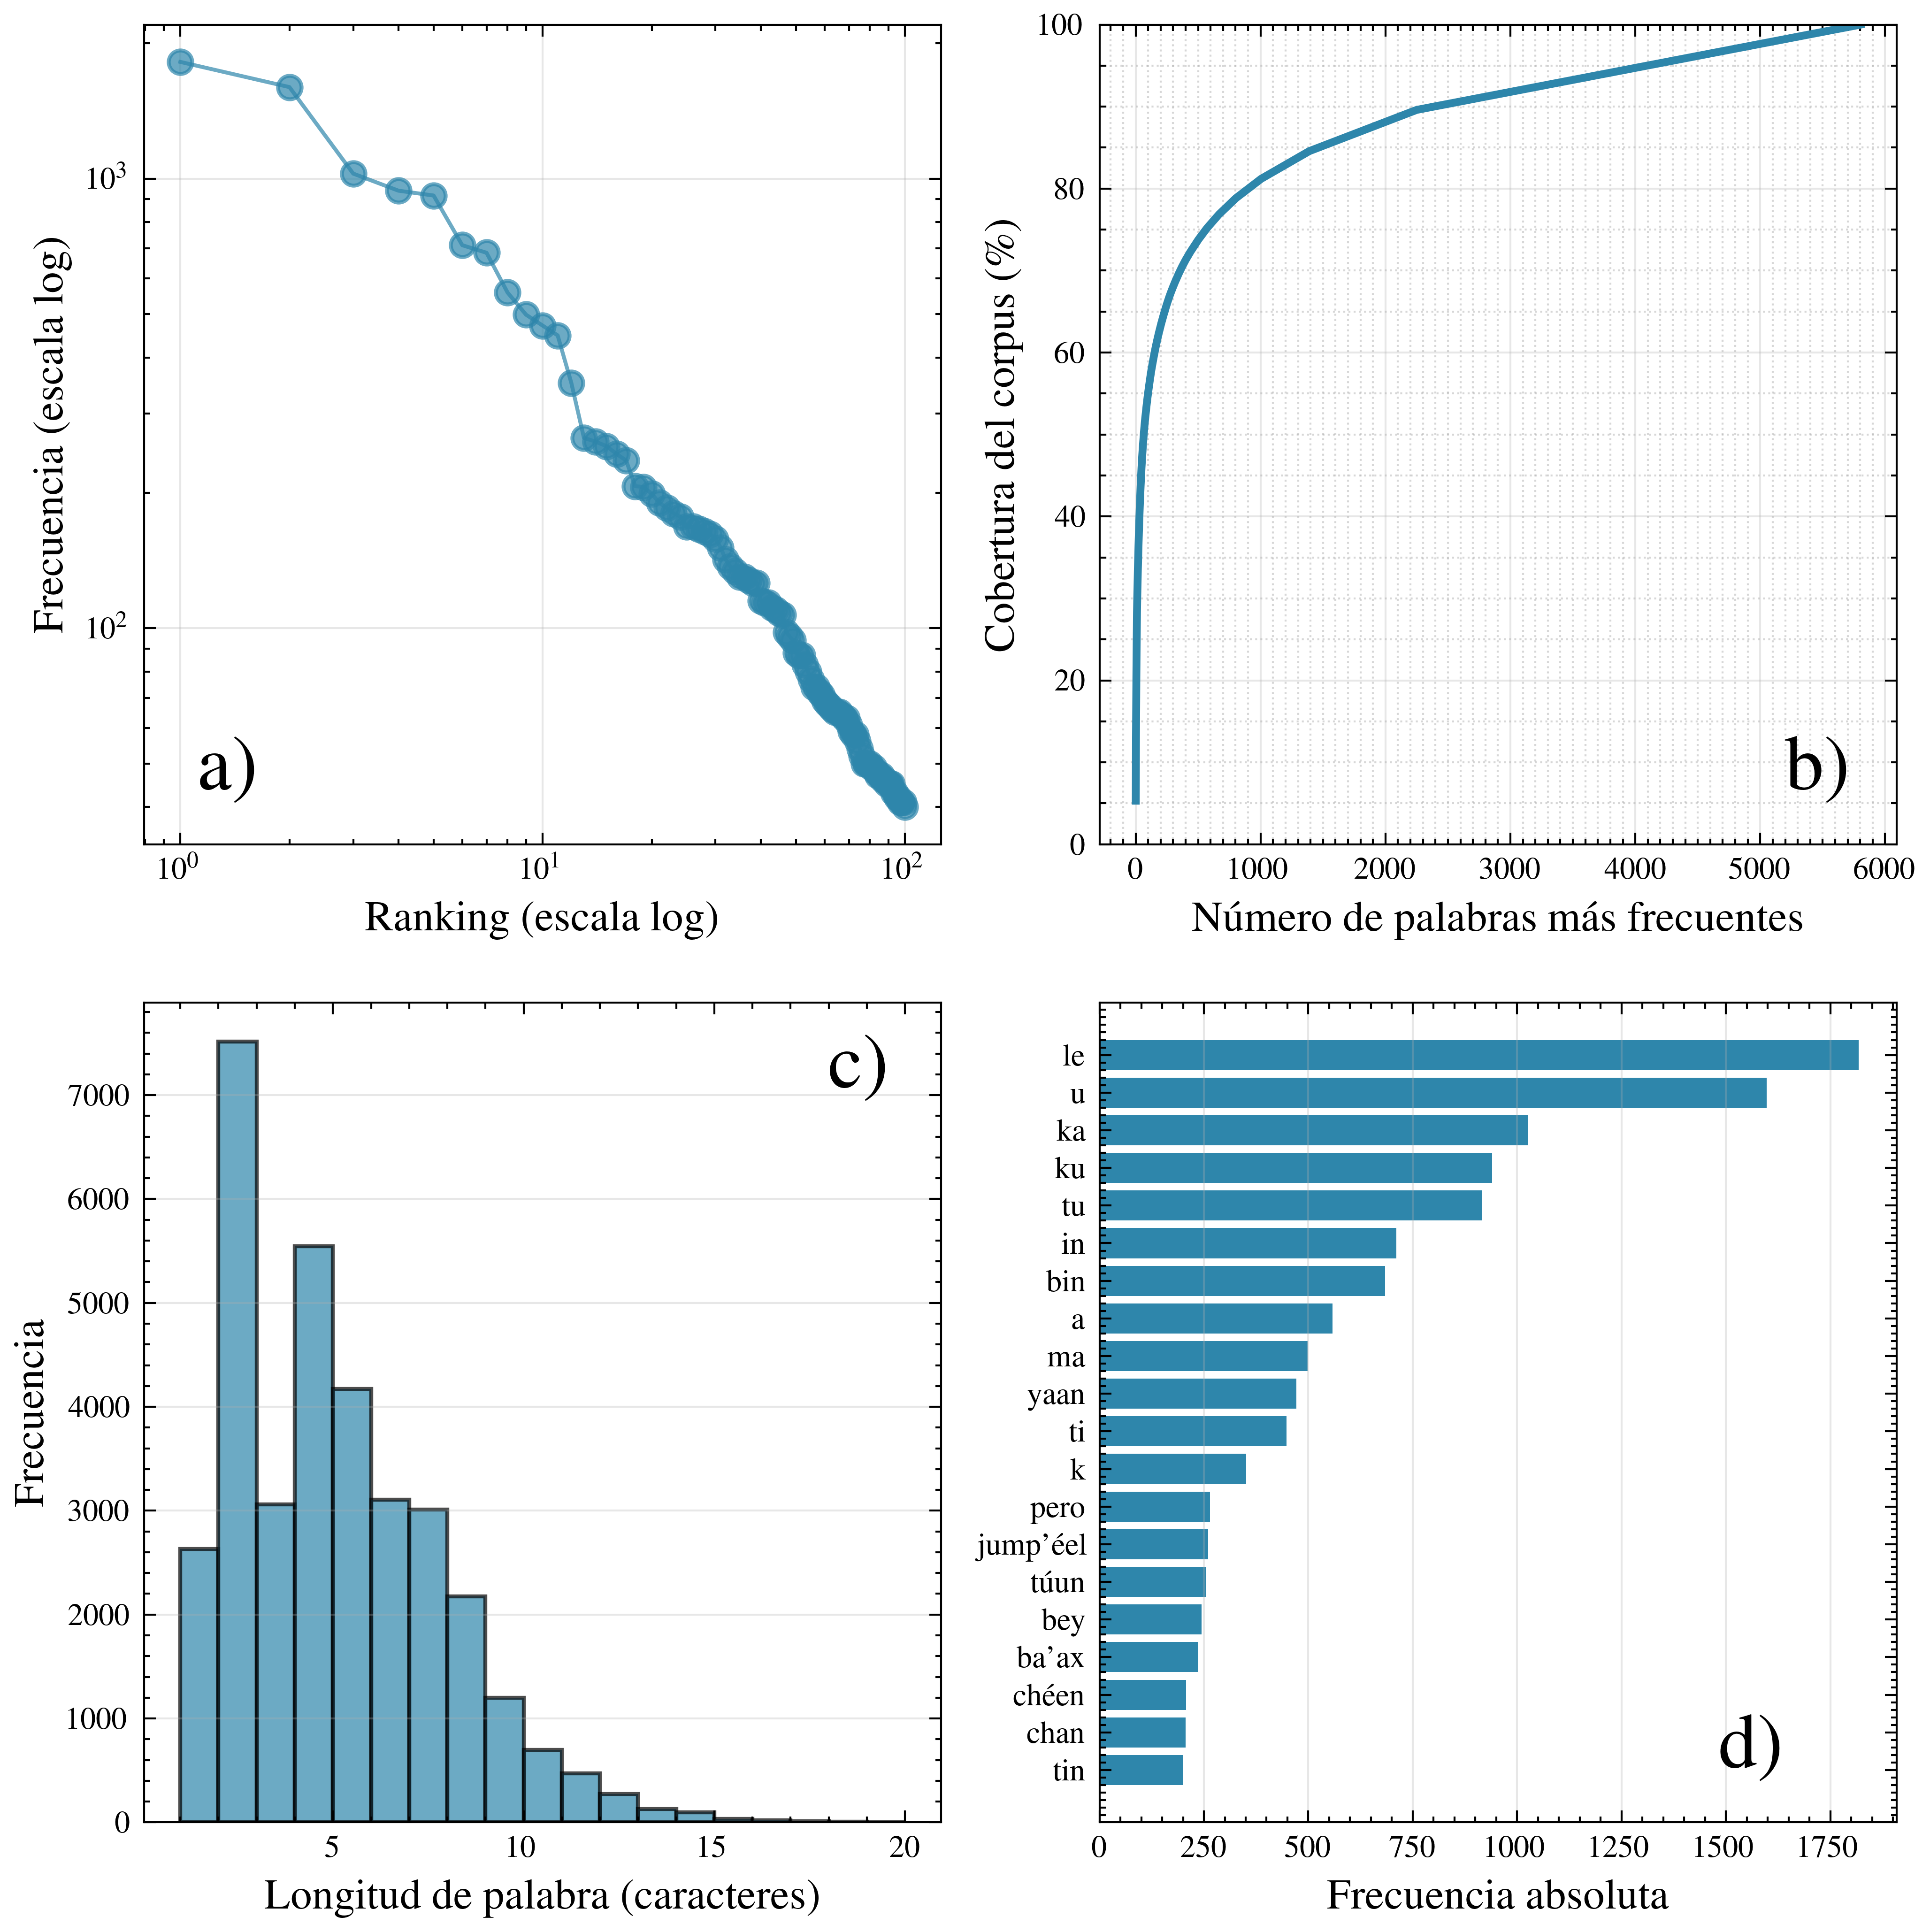

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MultipleLocator

def visualizar_analisis_lexico(resultados):
    # "Ley de Zipf: Distribución de frecuencias"
    # "Cobertura acumulada del vocabulario"
    # "Distribución de longitudes de palabras"
    # "20 palabras más frecuentes"

    fig = plt.figure(figsize=(7, 7))

    # --- a) Ley de Zipf ---
    ax1 = plt.subplot(2, 2, 1)
    df = resultados['df_frecuencias'].head(100)
    ax1.loglog(df['Rank'], df['Frecuencia'], 'o-', color='#2E86AB', alpha=0.7)
    ax1.set_xlabel('Ranking (escala log)', fontsize=11)
    ax1.set_ylabel('Frecuencia (escala log)', fontsize=11)
    ax1.text(0.07, 0.13, 'a)', transform=ax1.transAxes,
             fontsize=20, fontweight='bold', va='top')
    ax1.grid(True, alpha=0.3)

    # --- b) Cobertura acumulada ---
    ax2 = plt.subplot(2, 2, 2)
    df_plot = resultados['df_frecuencias']
    ax2.plot(df_plot['Rank'], df_plot['Freq. Acumulada'] * 100,
             color='#2E86AB', linewidth=2)
    ax2.set_xlabel('Número de palabras más frecuentes', fontsize=11)
    ax2.set_ylabel('Cobertura del corpus (\%)', fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.text(0.86, 0.13, 'b)', transform=ax2.transAxes,
             fontsize=20, fontweight='bold', va='top')
    ax2.legend()
    ax2.xaxis.set_minor_locator(MultipleLocator(100))   # líneas cada 50 palabras
    ax2.yaxis.set_minor_locator(MultipleLocator(5))    # líneas cada 5%
    ax2.grid(True, which='major', alpha=0.5)
    ax2.grid(True, which='minor', alpha=0.5, linestyle=':')
    ax2.grid(True, alpha=0.3)

    # --- c) Distribución de longitudes ---
    ax3 = plt.subplot(2, 2, 3)
    longitudes = [len(p) for p in resultados['palabras_lista']]
    ax3.hist(longitudes, bins=range(1, max(longitudes) + 2),
             color='#2E86AB', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Longitud de palabra (caracteres)', fontsize=11)
    ax3.set_ylabel('Frecuencia', fontsize=11)
    ax3.text(0.86, 0.96, 'c)', transform=ax3.transAxes,
             fontsize=20, fontweight='bold', va='top')
    ax3.grid(axis='y', alpha=0.3)

    # --- d) Top 20 palabras ---
    ax4 = plt.subplot(2, 2, 4)
    top20 = resultados['df_frecuencias'].head(20)
    ax4.barh(range(len(top20)), top20['Frecuencia'], color='#2E86AB')
    ax4.set_yticks(range(len(top20)))
    ax4.set_yticklabels(top20['Palabra'])
    ax4.invert_yaxis()
    ax4.set_xlabel('Frecuencia absoluta', fontsize=11)
    ax4.text(0.86, 0.13, 'd)', transform=ax4.transAxes,
             fontsize=20, fontweight='bold', va='top', ha='right')
    ax4.grid(axis='x', alpha=0.3)

    #plt.suptitle('Análisis Léxico del Corpus de Maya Yucateco',
    #             fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(h_pad=2)
    return fig

# Crear visualizaciones
with plt.style.context(['science', 'ieee']):
    fig = visualizar_analisis_lexico(resultados)
    plt.savefig(FIGURES / 'analisis_lexico_completo.png', dpi=300, bbox_inches='tight')
    plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\%'
<>:44: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_9311/282068951.py:44: SyntaxWarning: invalid escape sequence '\%'
  ax2.set_ylabel('Corpus coverage (\%)', fontsize=11)
/tmp/ipykernel_9311/282068951.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


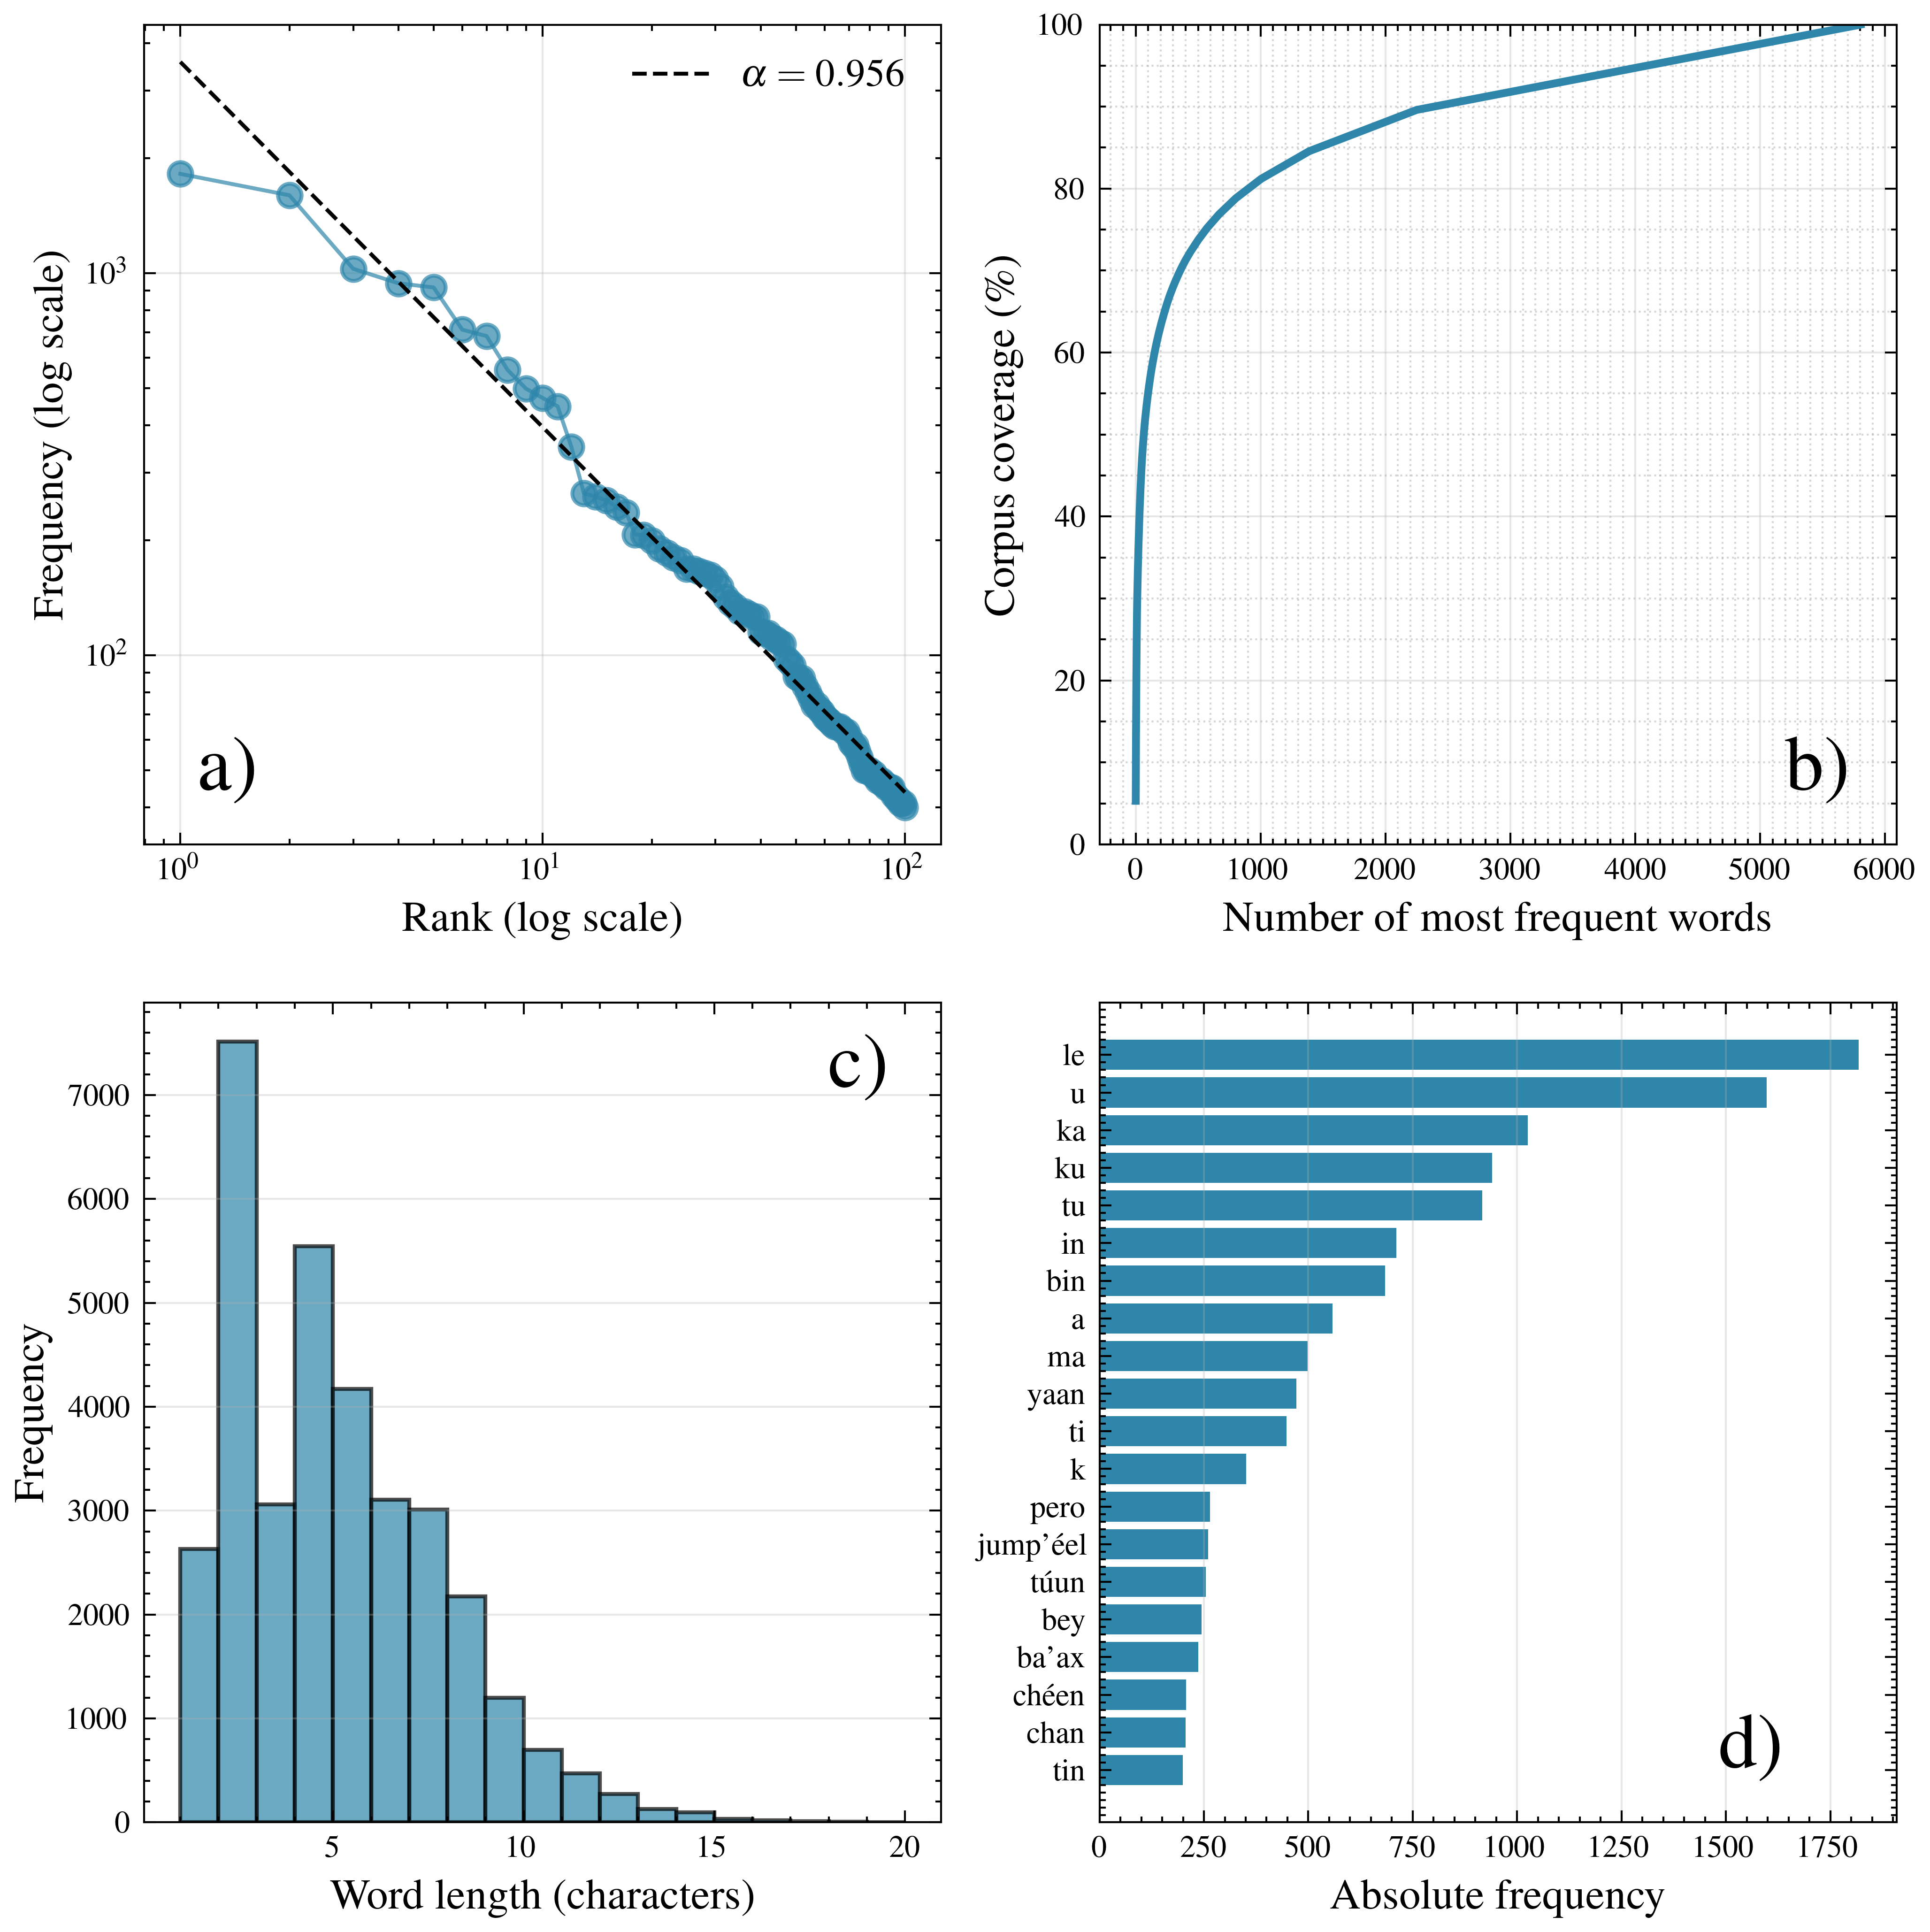

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MultipleLocator
from scipy import stats

def visualizar_analisis_lexico_paper(resultados):
    # "Ley de Zipf: Distribución de frecuencias"
    # "Cobertura acumulada del vocabulario"
    # "Distribución de longitudes de palabras"
    # "20 palabras más frecuentes"

    fig = plt.figure(figsize=(7, 7))

    # --- a) Ley de Zipf ---
    ax1 = plt.subplot(2, 2, 1)
    df = resultados['df_frecuencias'].head(100)
    ax1.loglog(df['Rank'], df['Frecuencia'], 'o-', color='#2E86AB', alpha=0.7)

    # Ajuste de la ley de Zipf en escala log-log:
    # log10(Frecuencia) = -alfa * log10(Rank) + intercepto
    log_rank = np.log10(df['Rank'].astype(float))
    log_freq = np.log10(df['Frecuencia'].astype(float))
    ajuste = stats.linregress(log_rank, log_freq)
    alfa = -ajuste.slope
    intercepto = ajuste.intercept
    freq_ajustada = 10**intercepto * df['Rank']**(-alfa)
    ax1.loglog(df['Rank'], freq_ajustada, '--', color='k',
               label=rf'$\alpha = {alfa:.3f}$')
    ax1.legend(loc='upper right', fontsize=10)

    ax1.set_xlabel('Rank (log scale)', fontsize=11)
    ax1.set_ylabel('Frequency (log scale)', fontsize=11)
    ax1.text(0.07, 0.13, 'a)', transform=ax1.transAxes,
             fontsize=20, fontweight='bold', va='top')
    ax1.grid(True, alpha=0.3)

    # --- b) Cobertura acumulada ---
    ax2 = plt.subplot(2, 2, 2)
    df_plot = resultados['df_frecuencias']
    ax2.plot(df_plot['Rank'], df_plot['Freq. Acumulada'] * 100,
             color='#2E86AB', linewidth=2)
    ax2.set_xlabel('Number of most frequent words', fontsize=11)
    ax2.set_ylabel('Corpus coverage (\%)', fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.text(0.86, 0.13, 'b)', transform=ax2.transAxes,
             fontsize=20, fontweight='bold', va='top')
    ax2.legend()
    ax2.xaxis.set_minor_locator(MultipleLocator(100))   # líneas cada 50 palabras
    ax2.yaxis.set_minor_locator(MultipleLocator(5))    # líneas cada 5%
    ax2.grid(True, which='major', alpha=0.5)
    ax2.grid(True, which='minor', alpha=0.5, linestyle=':')
    ax2.grid(True, alpha=0.3)

    # --- c) Distribución de longitudes ---
    ax3 = plt.subplot(2, 2, 3)
    longitudes = [len(p) for p in resultados['palabras_lista']]
    ax3.hist(longitudes, bins=range(1, max(longitudes) + 2),
             color='#2E86AB', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Word length (characters)', fontsize=11)
    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.text(0.86, 0.96, 'c)', transform=ax3.transAxes,
             fontsize=20, fontweight='bold', va='top')
    ax3.grid(axis='y', alpha=0.3)

    # --- d) Top 20 palabras ---
    ax4 = plt.subplot(2, 2, 4)
    top20 = resultados['df_frecuencias'].head(20)
    ax4.barh(range(len(top20)), top20['Frecuencia'], color='#2E86AB')
    ax4.set_yticks(range(len(top20)))
    ax4.set_yticklabels(top20['Palabra'])
    ax4.invert_yaxis()
    ax4.set_xlabel('Absolute frequency', fontsize=11)
    ax4.text(0.86, 0.13, 'd)', transform=ax4.transAxes,
             fontsize=20, fontweight='bold', va='top', ha='right')
    ax4.grid(axis='x', alpha=0.3)

    #plt.suptitle('Análisis Léxico del Corpus de Maya Yucateco',
    #             fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(h_pad=2)
    return fig

# Crear visualizaciones
with plt.style.context(['science', 'ieee']):
    fig = visualizar_analisis_lexico_paper(resultados)
    plt.savefig(FIGURES / 'analisis_lexico_completo_paper.pdf', dpi=300, bbox_inches='tight', format="pdf")
    plt.show()

In [9]:
def verificar_calidad_corpus(texto_corpus, resultados):
    """
    Identifica posibles problemas en el corpus
    """
    print("\n🔍 VERIFICACIÓN DE CALIDAD DEL CORPUS")
    print("="*60)
    
    # Caracteres extraños
    caracteres_usados = set(texto_corpus)
    print(f"\nCaracteres únicos encontrados ({len(caracteres_usados)}):")
    print(''.join(sorted(caracteres_usados)))
    
    # Posibles errores: números, signos raros
    palabras_con_numeros = [p for p in resultados['vocabulario'] 
                            if any(c.isdigit() for c in p)]
    if palabras_con_numeros:
        print(f"\n⚠️ Palabras con números ({len(palabras_con_numeros)}): ")
        print(palabras_con_numeros[:10])
    
    # Palabras muy largas (posibles errores)
    palabras_muy_largas = [p for p in resultados['vocabulario'] if len(p) > 20]
    if palabras_muy_largas:
        print(f"\n⚠️ Palabras muy largas (>20 chars): ")
        print(palabras_muy_largas)
    
    # Palabras de 1 letra
    palabras_1letra = [p for p in resultados['vocabulario'] if len(p) == 1]
    if palabras_1letra:
        print(f"\n⚠️ Palabras de 1 letra: {palabras_1letra}")

# Ejecutar verificación
verificar_calidad_corpus(texto, resultados)


🔍 VERIFICACIÓN DE CALIDAD DEL CORPUS

Caracteres únicos encontrados (49):

 $',-.012345:;abcdefghijklmnopqrstuvwxyz¿Úáéíñóú

⚠️ Palabras con números (3): 
['$50', '$25', '134']

⚠️ Palabras de 1 letra: ['j', 'i', 'o', 't', 'd', 'k', 'u', 'a', "'", 'x', 'y']


## Combinaaciones consonantes y vocales

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Basado en tu tokenizer y las normas de escritura
CONSONANTES_MAYA = [
    'B', 'CH', 'CH_G', 'J', 'K', 'K_G', 'L', 'M', 'N', 
    'P', 'P_G', 'R', 'S', 'T', 'T_G', 'TS', 'TS_G', 'W', 'X', 'Y',
    'D',  # préstamo
]

VOCALES_MAYA = [
    # Cortas
    'A', 'E', 'I', 'O', 'U',
    # Largas tono bajo
    'AA_L', 'EE_L', 'II_L', 'OO_L', 'UU_L',
    # Largas tono alto
    'AA_H', 'EE_H', 'II_H', 'OO_H', 'UU_H',
    # Glotalizadas
    'A_G', 'E_G', 'I_G', 'O_G', 'U_G',
    # Rearticuladas
    'A_RG', 'E_RG', 'I_RG', 'O_RG', 'U_RG',
]

# Para etiquetas más legibles en el gráfico
CONSONANTES_LABELS = [
    'b', 'ch', "ch'", 'j', 'k', "k'", 'l', 'm', 'n',
    'p', "p'", 'r', 's', 't', "t'", 'ts', "ts'", 'w', 'x', 'y',
    'd'
]

VOCALES_LABELS = [
    # Cortas
    'a', 'e', 'i', 'o', 'u',
    # Largas tono bajo
    'aa', 'ee', 'ii', 'oo', 'uu',
    # Largas tono alto
    'áa', 'ée', 'íi', 'óo', 'úu',
    # Glotalizadas
    "a'", "e'", "i'", "o'", "u'",
    # Rearticuladas
    "a'a", "e'e", "i'i", "o'o", "u'u",
]

print(f"Consonantes: {len(CONSONANTES_MAYA)}")
print(f"Vocales: {len(VOCALES_MAYA)}")
print(f"Matriz resultante: {len(CONSONANTES_MAYA)} × {len(VOCALES_MAYA)} = {len(CONSONANTES_MAYA) * len(VOCALES_MAYA)} celdas")

Consonantes: 21
Vocales: 25
Matriz resultante: 21 × 25 = 525 celdas


In [11]:
import pickle
from mayanlab.tokenizer import MayaPhonemeTokenizer 

def extraer_bigramas_cv(transcripciones_fonematicas):
    """
    Extrae bigramas Consonante-Vocal del corpus ya fonemizado.
    
    transcripciones_fonematicas: lista de strings donde cada string
    es una transcripción ya tokenizada (ej: "K A SIL B E E T I K")
    """
    bigramas_cv = Counter()
    
    for transcripcion in transcripciones_fonematicas:
        # Separar en fonemas
        fonemas = transcripcion.split()
        
        # Filtrar SIL
        fonemas = [f for f in fonemas if f != 'SIL']
        
        # Extraer bigramas C-V
        for i in range(len(fonemas) - 1):
            fonema1 = fonemas[i]
            fonema2 = fonemas[i + 1]
            
            # Verificar que sea C + V
            if fonema1 in CONSONANTES_MAYA and fonema2 in VOCALES_MAYA:
                bigrama = (fonema1, fonema2)
                bigramas_cv[bigrama] += 1
    
    return bigramas_cv

# Si tus transcripciones están en texto maya (no fonemizadas aún):
def extraer_bigramas_cv_desde_texto(textos_maya, tokenizer):
    """
    Versión que primero fonemiza el texto maya y luego extrae bigramas
    """
    transcripciones_fonematicas = []
    
    length = len(textos_maya)

    for i, texto in enumerate(textos_maya):
        print(f"try {i}/{length}")
        try:
            fonetico = tokenizer.tokenize(texto)
            transcripciones_fonematicas.append(fonetico)
        except Exception as e:
            print(f"Error al fonemizar '{texto[:50]}...': {e}")
            continue
    
    return extraer_bigramas_cv(transcripciones_fonematicas)

# Ejemplo de uso:
#tokenizer = MayaPhonemeTokenizer()
#bigramas_cv = extraer_bigramas_cv_desde_texto(textos, tokenizer)

# Guardar
#with open(FEATURES / "bigramas_cv.pkl", "wb") as f:
#    pickle.dump(bigramas_cv, f)

In [12]:
import pickle

with open(FEATURES / "bigramas_cv.pkl", "rb") as f:
    bigramas_cv = pickle.load(f)

bigramas_cv

Counter({('L', 'E'): 2807,
         ('K', 'A'): 1850,
         ('K', 'U'): 1496,
         ('B', 'I'): 1489,
         ('T', 'I'): 1481,
         ('T', 'U'): 1341,
         ('B', 'E'): 1098,
         ('T', 'E'): 1035,
         ('T', 'A'): 983,
         ('M', 'A'): 964,
         ('L', 'I'): 897,
         ('L', 'A'): 771,
         ('K', 'E'): 734,
         ('L', 'O'): 716,
         ('N', 'A'): 696,
         ('K', 'I'): 625,
         ('B', 'A_RG'): 620,
         ('N', 'I'): 617,
         ('N', 'E'): 612,
         ('Y', 'AA_L'): 598,
         ('M', 'AA_H'): 553,
         ('J', 'U'): 537,
         ('K', 'O'): 536,
         ('B', 'A'): 530,
         ('J', 'A'): 514,
         ('R', 'O'): 514,
         ('J', 'E'): 480,
         ('M', 'I'): 478,
         ('Y', 'A_RG'): 469,
         ('T', 'I_G'): 469,
         ('L', 'U'): 467,
         ('Y', 'A'): 462,
         ('N', 'U'): 452,
         ('M', 'E'): 450,
         ('K', 'O_RG'): 434,
         ('Y', 'O'): 427,
         ('T', 'UU_H'): 415,
         (

In [13]:
def crear_matriz_cv(bigramas_cv, consonantes=CONSONANTES_MAYA, vocales=VOCALES_MAYA):
    """
    Crea matriz de frecuencias Consonante × Vocal
    """
    n_cons = len(consonantes)
    n_voc = len(vocales)
    
    matriz = np.zeros((n_cons, n_voc))
    
    # Mapear fonemas a índices
    cons_idx = {c: i for i, c in enumerate(consonantes)}
    voc_idx = {v: i for i, v in enumerate(vocales)}
    
    # Llenar matriz
    for (cons, vocal), freq in bigramas_cv.items():
        if cons in cons_idx and vocal in voc_idx:
            i = cons_idx[cons]
            j = voc_idx[vocal]
            matriz[i, j] = freq
    
    return matriz

# Usar
matriz_cv = crear_matriz_cv(bigramas_cv)

In [14]:
def plot_heatmap_cv_maya(matriz, 
                         cons_labels=CONSONANTES_LABELS,
                         voc_labels=VOCALES_LABELS,
                         titulo="Distribución de combinaciones Consonante-Vocal en maya yucateco"):
    """
    Crea heatmap grande de consonantes × vocales
    """
    # Tamaño adaptado: 0.4 pulgadas por vocal, 0.35 por consonante
    ancho = max(18, len(voc_labels) * 0.4)
    alto = max(10, len(cons_labels) * 0.35)
    
    fig, ax = plt.subplots(figsize=(ancho, alto))
    
    # Usar log para mejor visualización (muchas celdas tendrán 0)
    # Añadir 1 para evitar log(0)
    matriz_log = np.log10(matriz + 1)
    
    # Crear heatmap
    im = ax.imshow(matriz_log, cmap='Greens', aspect='auto')
    
    # Configurar ejes
    ax.set_xticks(np.arange(len(voc_labels)))
    ax.set_yticks(np.arange(len(cons_labels)))
    ax.set_xticklabels(voc_labels, fontsize=22)
    ax.set_yticklabels(cons_labels, fontsize=22)
    
    # Rotar etiquetas del eje x para mejor legibilidad
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", 
             rotation_mode="anchor")
    
    # Grid sutil entre celdas
    ax.set_xticks(np.arange(len(voc_labels)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(cons_labels)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)
    ax.tick_params(axis="y", pad=10)
    ax.tick_params(axis="x", pad=10)
    
    # Labels
    ax.set_xlabel('Vowel (V)', fontsize=25, fontweight='bold', labelpad=10)
    ax.set_ylabel('Consonant (C)', fontsize=25, fontweight='bold', labelpad=10)
    #ax.set_title(titulo, fontsize=15, fontweight='bold', pad=20)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label(r'$\log_{10}(frequency + 1)$', rotation=270, labelpad=40, 
                   fontsize=22, fontweight='bold')
    
    # Ajustar layout
    plt.tight_layout()
    
    return fig

# Usar
with plt.style.context(['science', 'ieee']):
    plt.figure(figsize=(5, 3))
    fig = plot_heatmap_cv_maya(matriz_cv)
    plt.savefig(FIGURES / 'heatmap_cv_maya_paper.pdf', dpi=300, bbox_inches='tight', format="pdf")
    plt.savefig(FIGURES / 'heatmap_cv_maya_paper.svg', dpi=300, bbox_inches='tight', format="svg")
    plt.show()

<Figure size 3000x1800 with 0 Axes>

In [15]:
textos

array(['baach', 'chiich', "ch'íich'", ...,
       "le ku xkáakpachtiko'obe ma tu pak'o'obi ma tu pak'o'obi ma tu pak'o'obi le año je'elo yaanjij chéen jóok'ij teen xan man ti'ob",
       "teen xan man ti'ob weye camionadasil arroz kin bisik",
       "leten tene ya'ab ba'al juu ya'ab meyajnaja'anilen ya que bey yaanil túun le ba'alo hermano pues"],
      shape=(2535,), dtype=object)

In [16]:
CONSONANTES = ['b', 'ch', 'j', 'k', 'l', 'm', 'n', 'p', 'r', 's', 't', 'ts', 'w', 'x', 'y']
VOCALES = ['a', 'e', 'i', 'o', 'u', 'á', 'é', 'í', 'ó', 'ú']
GLOTAL = "'"

def tokenizar_palabra(word):
    """
    Convierte una palabra en lista de grafemas
    Maneja dígrafos (ch, ts) correctamente
    
    Ejemplo:
      "chak" → ['ch', 'a', 'k']
      "ts'ul" → ['ts', "'", 'u', 'l']
      "beetik" → ['b', 'e', 'e', 't', 'i', 'k']
    """
    grafemas = []
    i = 0
    
    while i < len(word):
        # Intentar primero dígrafos de 2 caracteres
        if i + 1 < len(word):
            digrafo = word[i:i+2]
            
            if digrafo in ['ch', 'ts']:
                grafemas.append(digrafo)
                i += 2  # Avanzar 2 posiciones
                continue
        
        # Si no es dígrafo, tomar 1 carácter
        grafemas.append(word[i])
        i += 1
    
    return grafemas

# ===== CLASIFICACIÓN =====
def check_type(grafema):
    """
    Clasifica un grafema en C, V, o ʔ
    
    Returns:
        0: Consonante
        1: Vocal
        2: Glotal
    """
    if grafema in CONSONANTES:
        return 0  # C
    elif grafema in VOCALES:
        return 1  # V
    elif grafema == GLOTAL:
        return 2  # ʔ
    else:
        raise ValueError(f"Grafema no reconocido: '{grafema}'")

def get_pair_indices(word):
    """
    Obtiene índices de transiciones para una palabra
    
    Returns:
        Lista de tuplas (índice_origen, índice_destino)
    """
    # 1. Tokenizar
    grafemas = tokenizar_palabra(word.lower())
    
    # 2. Convertir a índices
    indices = []
    for grafema in grafemas:
        try:
            idx = check_type(grafema)
            indices.append(idx)
        except ValueError as e:
            print(f"Advertencia: {e}")
            continue
    
    # 3. Extraer pares consecutivos
    pares = []
    for i in range(len(indices) - 1):
        par = (indices[i], indices[i+1])
        pares.append(par)
    
    return pares, grafemas

# ===== EJEMPLOS DE USO =====
ejemplos = [
    "chak",      # ch + a + k → C V C
    "ts'ul",     # ts + ' + u + l → C ʔ V C
    "beetik",    # b + e + e + t + i + k → C V V C V C
    "k'aak'",    # k + ' + a + a + k + ' → C ʔ V V C ʔ
    "a'a",       # a + ' + a → V ʔ V (rearticulada)
]

for palabra in ejemplos:
    pares, grafemas = get_pair_indices(palabra)
    
    # Convertir índices a letras para visualizar
    tipos = {0: 'C', 1: 'V', 2: 'ʔ'}
    secuencia = ' → '.join([tipos[check_type(g)] for g in grafemas])
    
    print(f"\nPalabra: '{palabra}'")
    print(f"  Grafemas: {grafemas}")
    print(f"  Secuencia: {secuencia}")
    print(f"  Pares: {pares}")


Palabra: 'chak'
  Grafemas: ['ch', 'a', 'k']
  Secuencia: C → V → C
  Pares: [(0, 1), (1, 0)]

Palabra: 'ts'ul'
  Grafemas: ['ts', "'", 'u', 'l']
  Secuencia: C → ʔ → V → C
  Pares: [(0, 2), (2, 1), (1, 0)]

Palabra: 'beetik'
  Grafemas: ['b', 'e', 'e', 't', 'i', 'k']
  Secuencia: C → V → V → C → V → C
  Pares: [(0, 1), (1, 1), (1, 0), (0, 1), (1, 0)]

Palabra: 'k'aak''
  Grafemas: ['k', "'", 'a', 'a', 'k', "'"]
  Secuencia: C → ʔ → V → V → C → ʔ
  Pares: [(0, 2), (2, 1), (1, 1), (1, 0), (0, 2)]

Palabra: 'a'a'
  Grafemas: ['a', "'", 'a']
  Secuencia: V → ʔ → V
  Pares: [(1, 2), (2, 1)]


In [17]:
matriz = np.zeros(shape=(3,3))
print(matriz)

for word in textos:
    pares, _ = get_pair_indices(word)
    for (i, j) in pares:
        matriz[i, j] += 1

matriz

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Advertencia: Grafema no reconocido: ' '
Adv

array([[1.6917e+04, 4.8092e+04, 3.0460e+03],
       [4.9792e+04, 1.2562e+04, 7.7980e+03],
       [4.9600e+02, 9.9580e+03, 1.0000e+00]])

In [18]:
matriz_prob = matriz / matriz.sum(axis=1, keepdims=True)
matriz_prob

array([[2.48578356e-01, 7.06663728e-01, 4.47579164e-02],
       [7.09773064e-01, 1.79068309e-01, 1.11158627e-01],
       [4.74414156e-02, 9.52462936e-01, 9.56480153e-05]])

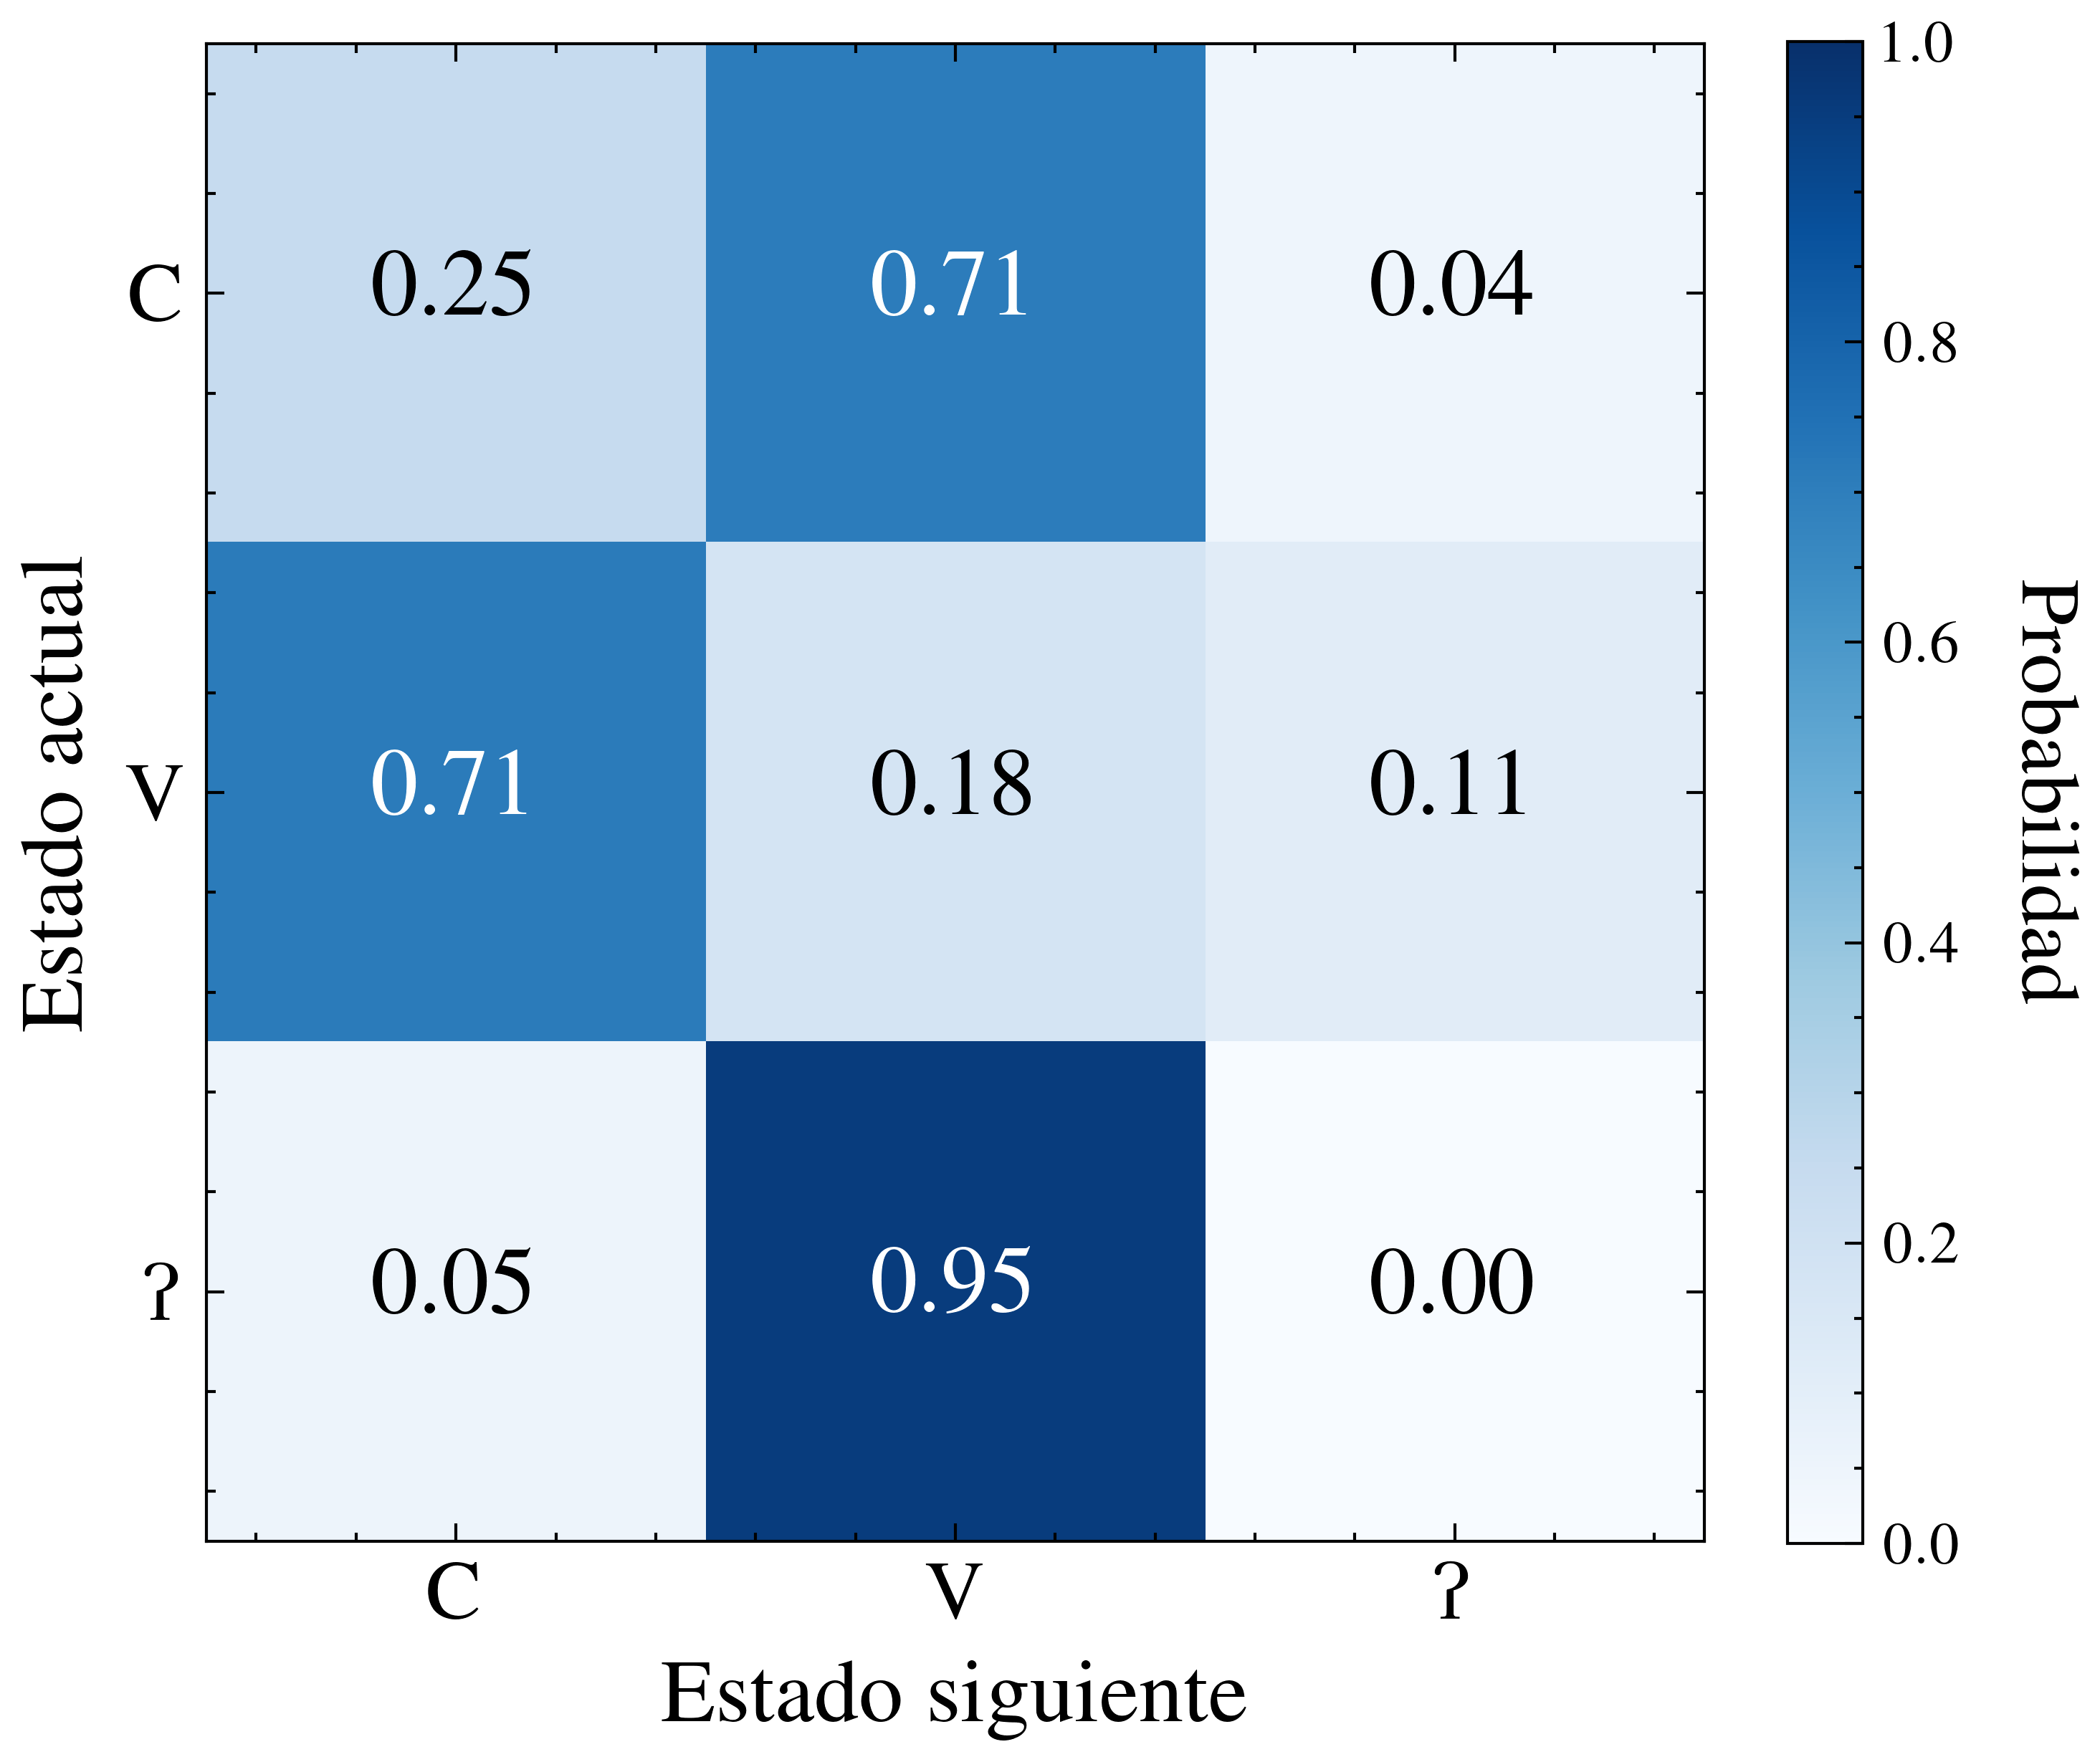

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{tipa}'

def plot_heatmap_simple(matriz_prob, estados=['C', 'V', r'\textipa{P}']):
    """
    Heatmap simple y rápido de la matriz de transición
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Heatmap
    im = ax.imshow(matriz_prob, cmap='Blues', vmin=0, vmax=1)
    
    # Ejes
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(estados, fontsize=14, fontweight='bold')
    ax.set_yticklabels(estados, fontsize=14, fontweight='bold')
    
    ax.set_xlabel('Estado siguiente', fontsize=15, fontweight='bold')
    ax.set_ylabel('Estado actual', fontsize=15, fontweight='bold')
    
    # Valores en las celdas
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, f'{matriz_prob[i, j]:.2f}',
                          ha="center", va="center",
                          color="white" if matriz_prob[i, j] > 0.5 else "black",
                          fontsize=16, fontweight='bold')
    
    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.05, shrink=0.78)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Probabilidad", rotation=270, labelpad=20, 
                   fontsize=14, fontweight='bold')

    fig.tight_layout()
    
    return fig
# Usar
with plt.style.context(['science', 'ieee']):
    plt.rcParams['text.latex.preamble'] = r'\usepackage{tipa}'
    fig = plot_heatmap_simple(matriz_prob)
    plt.savefig(FIGURES / 'heatmap_cvg_maya.svg', dpi=300, bbox_inches='tight')
    plt.show()

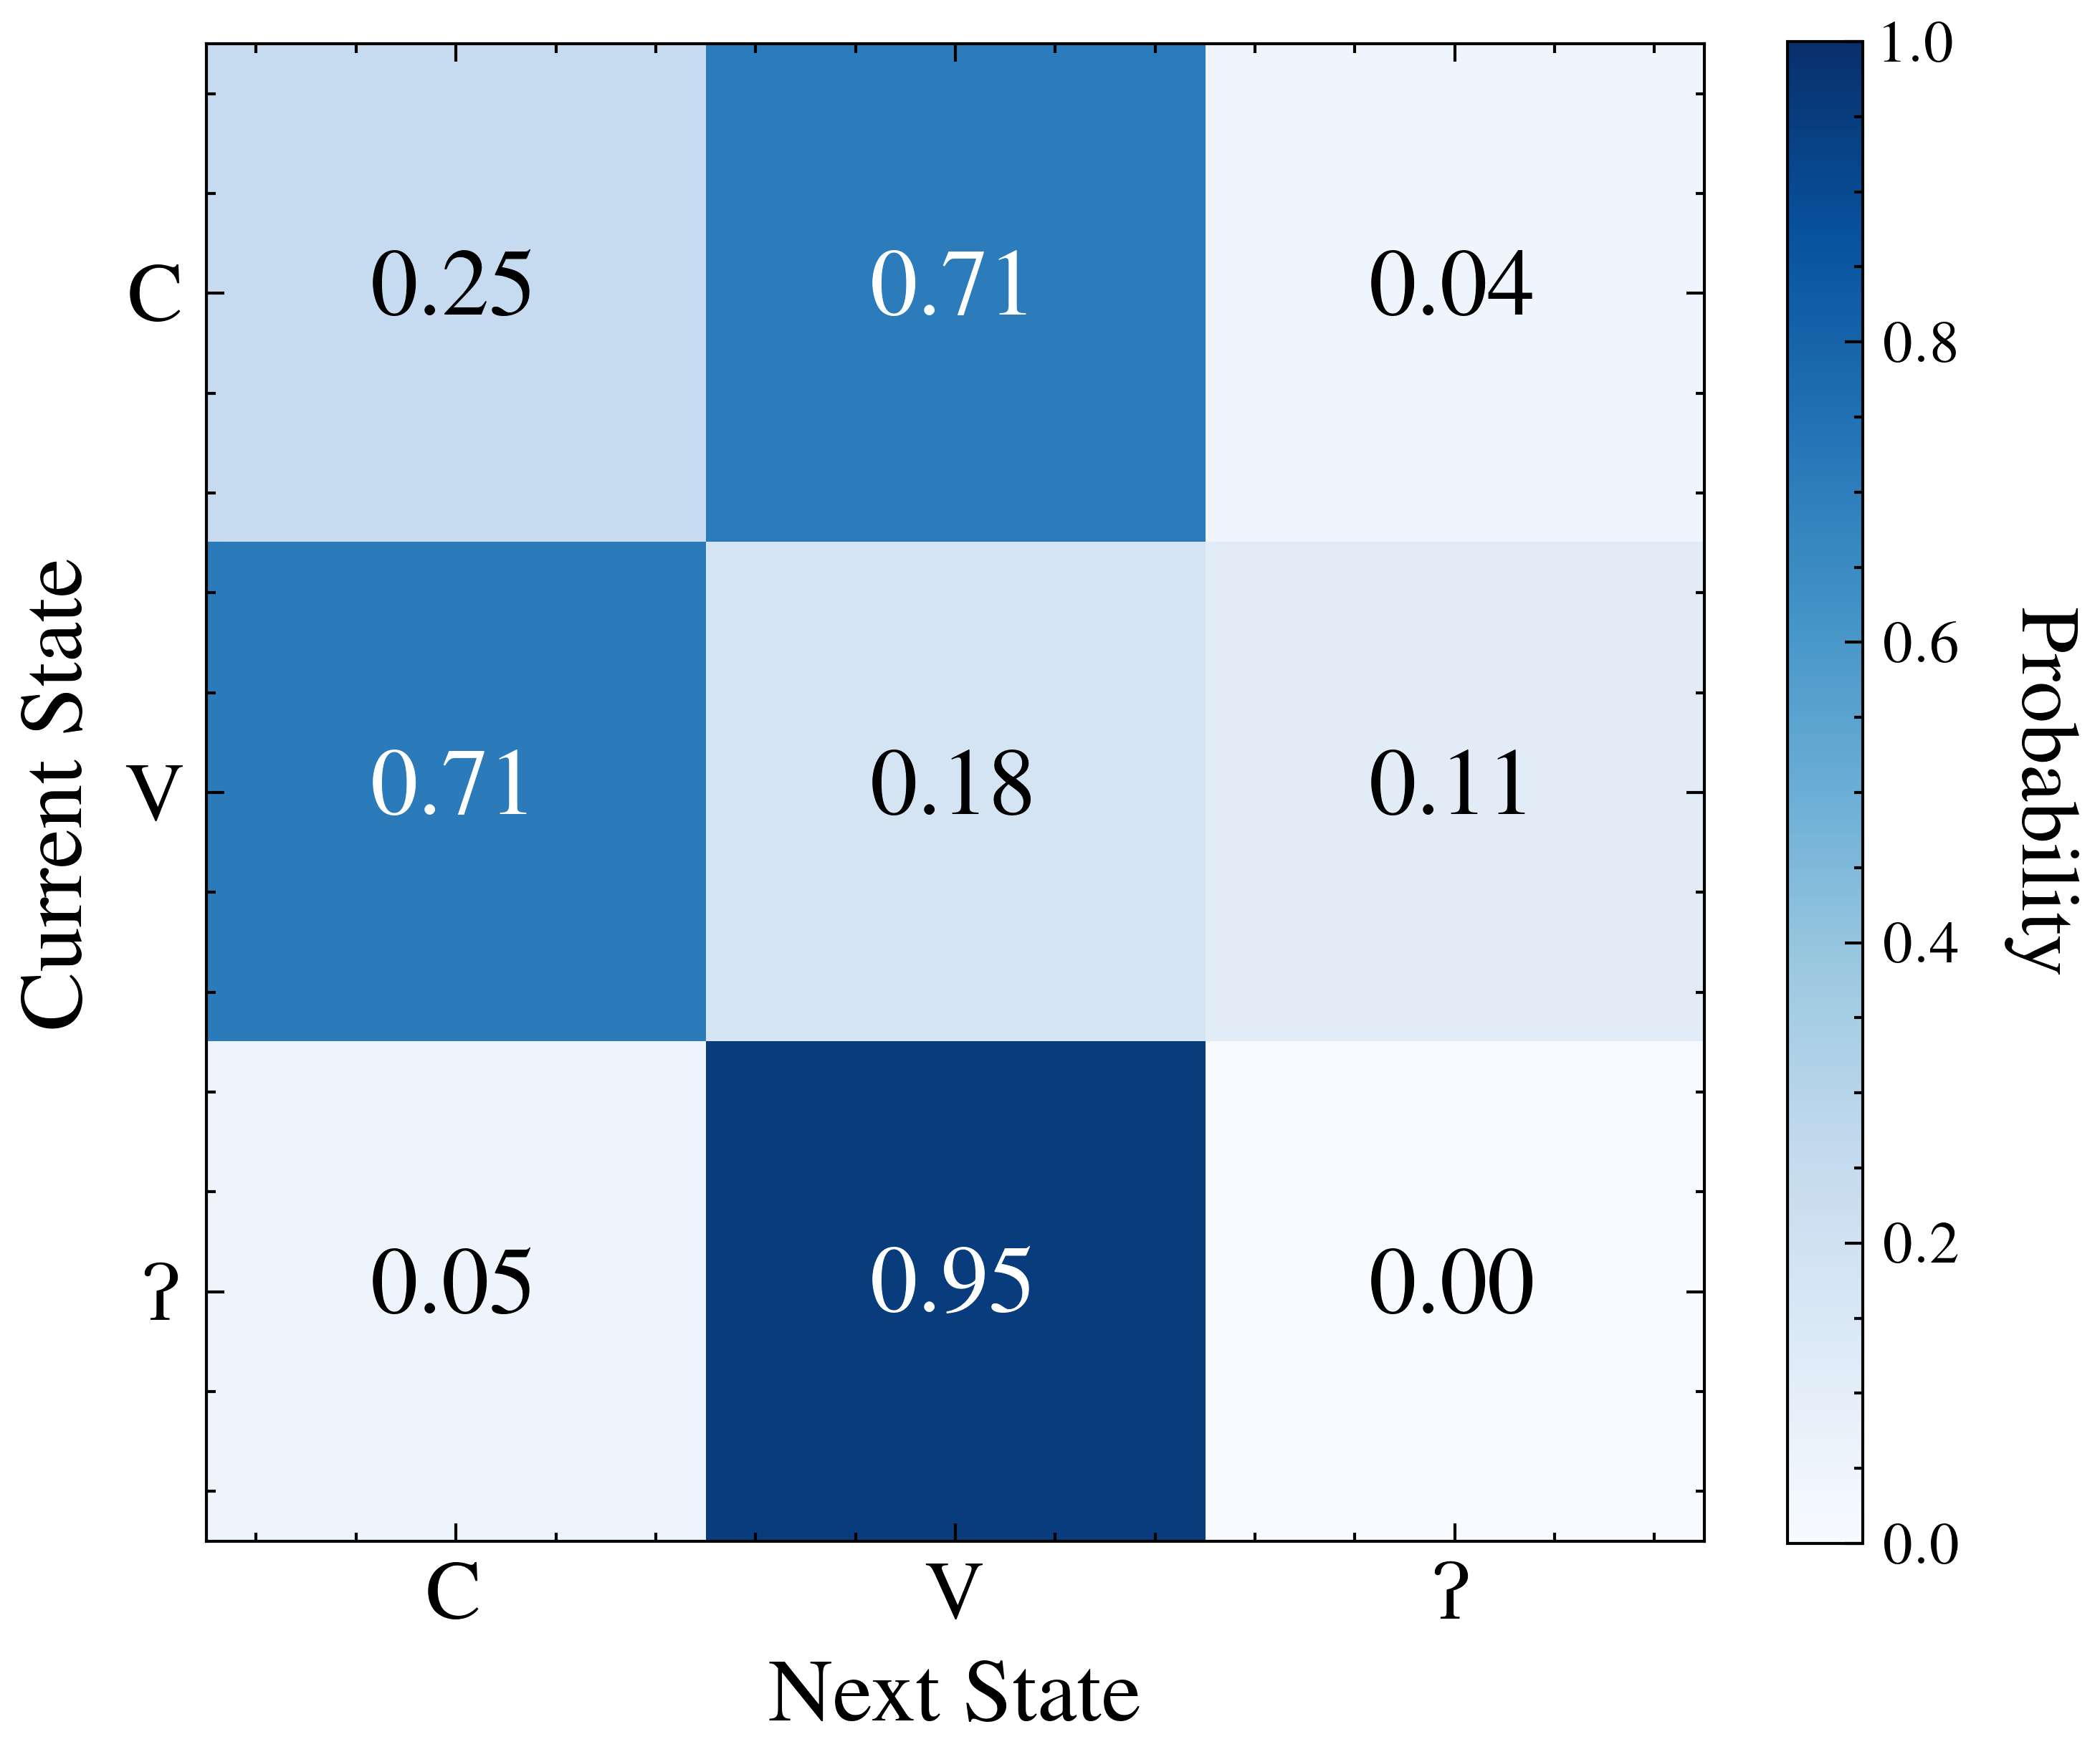

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{tipa}'

def plot_heatmap_simple_paper(matriz_prob, estados=['C', 'V', r'\textipa{P}']):
    """
    Heatmap simple y rápido de la matriz de transición
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Heatmap
    im = ax.imshow(matriz_prob, cmap='Blues', vmin=0, vmax=1)
    
    # Ejes
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(estados, fontsize=14, fontweight='bold')
    ax.set_yticklabels(estados, fontsize=14, fontweight='bold')
    
    ax.set_xlabel('Next State', fontsize=15, fontweight='bold')
    ax.set_ylabel('Current State', fontsize=15, fontweight='bold')
    
    # Valores en las celdas
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, f'{matriz_prob[i, j]:.2f}',
                          ha="center", va="center",
                          color="white" if matriz_prob[i, j] > 0.5 else "black",
                          fontsize=16, fontweight='bold')
    
    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.05, shrink=0.78)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Probability", rotation=270, labelpad=20, 
                   fontsize=14, fontweight='bold')

    fig.tight_layout()
    
    return fig
# Usar
with plt.style.context(['science', 'ieee']):
    plt.rcParams['text.latex.preamble'] = r'\usepackage{tipa}'
    fig = plot_heatmap_simple_paper(matriz_prob)
    plt.savefig(FIGURES / 'heatmap_cvg_maya_paper.pdf', dpi=300, bbox_inches='tight', format="pdf")
    plt.show()